In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

对比不同解码方式的rollout

In [2]:
import re
import numpy as np
from pathlib import Path
from collections import Counter

def parse_diversity_line(line):
    """
    解析单行diversity数据，提取完整信息
    示例: diversity| distinct_answer_num: 6 | all_answer_num: 8 | distinct_answer_ratio: 0.75 | best_answer_ratio: 0.38 | correct_answer_number: 1 | best_is_correct: 0 | extracted_answers: ['0', '33.33', '22', '33.33', '33.33', '36.25', '24', '42'] | majority_answer: 33.33 | ground_truth_answer: 22
    """
    # 解析基础指标
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if not match:
        return None
    
    # 提取答案列表
    answers_pattern = r'extracted_answers:\s*\[(.*?)\]'
    answers_match = re.search(answers_pattern, line)
    extracted_answers = []
    if answers_match:
        # 解析答案列表字符串
        answers_str = answers_match.group(1)
        # 处理引号内的内容
        extracted_answers = re.findall(r"'([^']*)'", answers_str)
    
    # 提取多数投票答案
    majority_pattern = r'majority_answer:\s*([^\s|]+)'
    majority_match = re.search(majority_pattern, line)
    majority_answer = majority_match.group(1) if majority_match else None
    
    # 提取真实答案
    truth_pattern = r'ground_truth_answer:\s*([^\s|]+)'
    truth_match = re.search(truth_pattern, line)
    ground_truth = truth_match.group(1) if truth_match else None
    
    return {
        'distinct_answer_num': int(match.group(1)),
        'all_answer_num': int(match.group(2)),
        'best_answer_ratio': float(match.group(3)),
        'correct_answer_number': int(match.group(4)),
        'best_is_correct': int(match.group(5)),
        'extracted_answers': extracted_answers,
        'majority_answer': majority_answer,
        'ground_truth': ground_truth
    }

def calculate_reward_metrics(answers, majority_answer, ground_truth):
    """
    计算reward accuracy和相关指标
    
    Args:
        answers: 所有rollout的答案列表
        majority_answer: 多数投票答案
        ground_truth: 真实答案
    
    Returns:
        dict: 包含各项指标
    """
    n = len(answers)
    if n == 0 or majority_answer is None or ground_truth is None:
        return {
            'reward_accuracy': 0,
            'true_positive_ratio': 0,
            'true_negative_ratio': 0,
            'false_positive_ratio': 0,
            'false_negative_ratio': 0
        }
    
    # 为每个rollout计算估计奖励和真实奖励
    tp = fp = tn = fn = 0
    
    for ans in answers:
        est_reward = 1 if ans == majority_answer else 0  # 估计奖励：是否匹配多数投票
        true_reward = 1 if ans == ground_truth else 0     # 真实奖励：是否真实正确
        
        if est_reward == 1 and true_reward == 1:
            tp += 1  # True Positive: 估计正确且真实正确
        elif est_reward == 1 and true_reward == 0:
            fp += 1  # False Positive: 估计正确但真实错误
        elif est_reward == 0 and true_reward == 1:
            fn += 1  # False Negative: 估计错误但真实正确
        elif est_reward == 0 and true_reward == 0:
            tn += 1  # True Negative: 估计错误且真实错误
    
    # 计算各项指标
    total = tp + fp + tn + fn
    
    # Reward Accuracy: 估计奖励与真实奖励一致的比例
    reward_accuracy = (tp + tn) / total if total > 0 else 0
    
    # True Positive Ratio: TP / (TP + FN)
    true_positive_ratio = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # True Negative Ratio: TN / (TN + FP)
    true_negative_ratio = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Positive Ratio: FP / (FP + TN)
    false_positive_ratio = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # False Negative Ratio: FN / (FN + TP)
    false_negative_ratio = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    return {
        'reward_accuracy': reward_accuracy,
        'true_positive_ratio': true_positive_ratio,
        'true_negative_ratio': true_negative_ratio,
        'false_positive_ratio': false_positive_ratio,
        'false_negative_ratio': false_negative_ratio,
        # 也返回原始计数以便调试
        'tp_count': tp,
        'fp_count': fp,
        'tn_count': tn,
        'fn_count': fn
    }

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    过滤掉所有rollout相同的样本（无法产生梯度）
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0,
            'good_reward_ratio': 0,
            'zero_reward_ratio': 0,
            'bad_reward_ratio': 0,
            'effective_sample_ratio': 0,  # 有效样本比例（distinct_num > 1）
            'effective_reward_accuracy': 0,  # 有效样本中的reward accuracy
            'effective_tp_ratio': 0,
            'effective_fp_ratio': 0,
            'effective_tn_ratio': 0,
            'effective_fn_ratio': 0,
            'overall_reward_accuracy': 0,  # 所有样本（包括无效）的reward accuracy（供参考）
        }
    
    n_samples = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']
    
    # 原有的指标计算
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    avg_accuracy = avg_correct_num / all_answer_num
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    # 样本类型比例
    good_reward_count = zero_reward_count = bad_reward_count = 0
    for d in data_list:
        if d['distinct_answer_num'] == 1:
            zero_reward_count += 1
        elif d['best_is_correct'] == 1:
            good_reward_count += 1
        else:
            bad_reward_count += 1
    
    # ========== 有效样本过滤 ==========
    # 有效样本：distinct_answer_num > 1（有多样性，能产生梯度）
    effective_samples = [d for d in data_list if d['distinct_answer_num'] > 1]
    effective_sample_ratio = len(effective_samples) / n_samples if n_samples > 0 else 0
    
    # 在所有样本上计算overall reward accuracy（包括无效样本）
    total_tp_all = total_fp_all = total_tn_all = total_fn_all = 0
    
    # 在有效样本上计算effective reward metrics
    total_tp_eff = total_fp_eff = total_tn_eff = total_fn_eff = 0
    
    for d in data_list:
        if 'extracted_answers' not in d or not d['majority_answer'] or not d['ground_truth']:
            continue
            
        answers = d['extracted_answers']
        majority = d['majority_answer']
        truth = d['ground_truth']
        is_effective = d['distinct_answer_num'] > 1
        
        for ans in answers:
            est_reward = 1 if ans == majority else 0
            true_reward = 1 if ans == truth else 0
            
            # 统计所有样本
            if est_reward == 1 and true_reward == 1:
                total_tp_all += 1
            elif est_reward == 1 and true_reward == 0:
                total_fp_all += 1
            elif est_reward == 0 and true_reward == 0:
                total_tn_all += 1
            elif est_reward == 0 and true_reward == 1:
                total_fn_all += 1
            
            # 只统计有效样本
            if is_effective:
                if est_reward == 1 and true_reward == 1:
                    total_tp_eff += 1
                elif est_reward == 1 and true_reward == 0:
                    total_fp_eff += 1
                elif est_reward == 0 and true_reward == 0:
                    total_tn_eff += 1
                elif est_reward == 0 and true_reward == 1:
                    total_fn_eff += 1
    
    # 计算overall指标（所有样本）
    total_rollouts_all = total_tp_all + total_fp_all + total_tn_all + total_fn_all
    if total_rollouts_all > 0:
        overall_reward_accuracy = (total_tp_all + total_tn_all) / total_rollouts_all
        overall_tp_ratio = total_tp_all / total_rollouts_all
        overall_fp_ratio = total_fp_all / total_rollouts_all
        overall_tn_ratio = total_tn_all / total_rollouts_all
        overall_fn_ratio = total_fn_all / total_rollouts_all
    else:
        overall_reward_accuracy = overall_tp_ratio = overall_fp_ratio = overall_tn_ratio = overall_fn_ratio = 0
    
    # 计算effective指标（只有有效样本）
    total_rollouts_eff = total_tp_eff + total_fp_eff + total_tn_eff + total_fn_eff
    if total_rollouts_eff > 0:
        effective_reward_accuracy = (total_tp_eff + total_tn_eff) / total_rollouts_eff
        effective_tp_ratio = total_tp_eff / total_rollouts_eff
        effective_fp_ratio = total_fp_eff / total_rollouts_eff
        effective_tn_ratio = total_tn_eff / total_rollouts_eff
        effective_fn_ratio = total_fn_eff / total_rollouts_eff
    else:
        effective_reward_accuracy = effective_tp_ratio = effective_fp_ratio = effective_tn_ratio = effective_fn_ratio = 0
    
    # 验证有效样本的比例之和为1
    if total_rollouts_eff > 0:
        assert abs(effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio - 1.0) < 1e-10, \
               f"有效样本比例之和应为1，实际为{effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio}"
    
    return {
        # 原有指标
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,
        'num_samples': n_samples,
        'good_reward_ratio': good_reward_count / n_samples,
        'zero_reward_ratio': zero_reward_count / n_samples,
        'bad_reward_ratio': bad_reward_count / n_samples,
        
        # 新增：有效样本比例
        'effective_sample_ratio': effective_sample_ratio,
        
        # 有效样本上的reward metrics
        'effective_reward_accuracy': effective_reward_accuracy,
        'effective_tp_ratio': effective_tp_ratio,
        'effective_fp_ratio': effective_fp_ratio,
        'effective_tn_ratio': effective_tn_ratio,
        'effective_fn_ratio': effective_fn_ratio,
        
        # 整体指标（供参考）
        'overall_reward_accuracy': overall_reward_accuracy,
    }

def print_metrics_table(metrics_list):
    """
    打印指标表格（包含有效样本指标）
    """
    print("\n" + "="*200)
    header = f"{'File':<60} {'Samples':<6} {'Eff%':<6} {'Distinct':<8} {'Consist':<7} {'RollAcc':<7} {'VoteAcc':<7} "
    header += f"{'GoodR':<6} {'ZeroR':<6} {'BadR':<6} "
    header += f"{'EffTP':<6} {'EffFP':<6} {'EffTN':<6} {'EffFN':<6} {'EffRewAcc':<8} {'AllRewAcc':<8}"
    print(header)
    print("="*200)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:60] + ".." if len(metrics['filename']) > 40 else metrics['filename']
            print(f"{filename:<60} {metrics['num_samples']:<6} "
                  f"{metrics['effective_sample_ratio']:<6.2f} "
                  f"{metrics['avg_distinct_num']:<8.2f} "
                  f"{metrics['consistency']:<7.3f} "
                  f"{metrics['avg_accuracy']:<7.3f} "
                  f"{metrics['voting_accuracy']:<7.3f} "
                  f"{metrics['good_reward_ratio']:<6.3f} "
                  f"{metrics['zero_reward_ratio']:<6.3f} "
                  f"{metrics['bad_reward_ratio']:<6.3f} "
                  f"{metrics['effective_tp_ratio']:<6.3f} "
                  f"{metrics['effective_fp_ratio']:<6.3f} "
                  f"{metrics['effective_tn_ratio']:<6.3f} "
                  f"{metrics['effective_fn_ratio']:<6.3f} "
                  f"{metrics['effective_reward_accuracy']:<8.3f} "
                  f"{metrics['overall_reward_accuracy']:<8.3f}")
    
    print("="*200)
    print("\n指标说明:")
    print("  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)")
    print("  Distinct: 平均不同答案数量")
    print("  Consist:  一致性 (最常见答案比例)")
    print("  RollAcc:  rollout平均准确率")
    print("  VoteAcc:  投票准确率")
    print("  GoodR:    好样本比例 (投票正确且多样)")
    print("  ZeroR:    零奖励比例 (无多样性)")
    print("  BadR:     坏样本比例 (投票错误)")
    print("  EffTP:    有效样本中估计正确且真实正确比例")
    print("  EffFP:    有效样本中估计正确但真实错误比例") 
    print("  EffTN:    有效样本中估计错误且真实错误比例")
    print("  EffFN:    有效样本中估计错误但真实正确比例")
    print("  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)")
    print("  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)")
    print(f"\n  验证: EffTP+EffFP+EffTN+EffFN = {metrics['effective_tp_ratio']+metrics['effective_fp_ratio']+metrics['effective_tn_ratio']+metrics['effective_fn_ratio']:.3f} (应为1)")

def process_file(filename, max_line=0):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    if max_line > 0:
        data_list = data_list[:max_line]
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics


In [5]:
# 画表格
log_files = [
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32.log',
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32_weighted_confidence.log',
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file, max_line=80)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

Processing logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32.log...
Processing logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32_weighted_confidence.log...

File                                                         Samples Eff%   Distinct Consist RollAcc VoteAcc GoodR  ZeroR  BadR   EffTP  EffFP  EffTN  EffFN  EffRewAcc AllRewAcc
checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_lev.. 80     0.62   3.12     0.769   0.635   0.662   0.300  0.375  0.325  0.219  0.282  0.443  0.056  0.662    0.765   
checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_lev.. 80     0.60   3.04     0.780   0.624   0.662   0.287  0.400  0.312  0.229  0.267  0.451  0.053  0.680    0.773   

指标说明:
  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)
  Distinct: 平均不同答案数量
  Consist:  一致性 (最常见答案比例)
  RollAcc:  rollout平均准确率
  VoteAcc:  投票准确率
  GoodR:    好样本比例 (投票正确且多样)
  ZeroR:    零奖励比例 (无多样性)
  BadR:     坏样本比例 (投票错误)
  EffTP:    有效样本中估计正确且

训练过程中的metric曲线

280 points for pseudo_label_acc in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for pseudo_label_acc in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/pseudo_label_acc.png


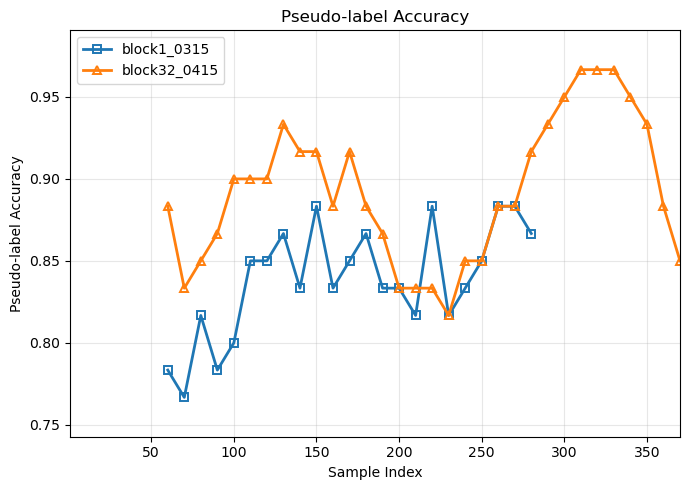

280 points for reward_acc in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for reward_acc in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/reward_acc.png


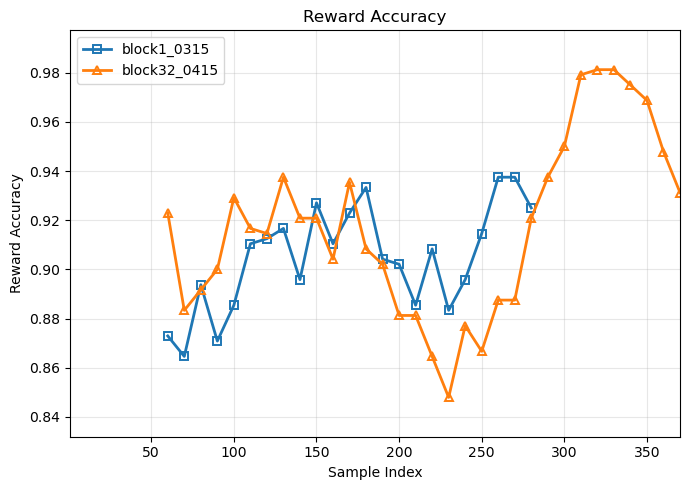

280 points for valid_reward_acc in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for valid_reward_acc in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/valid_reward_acc.png


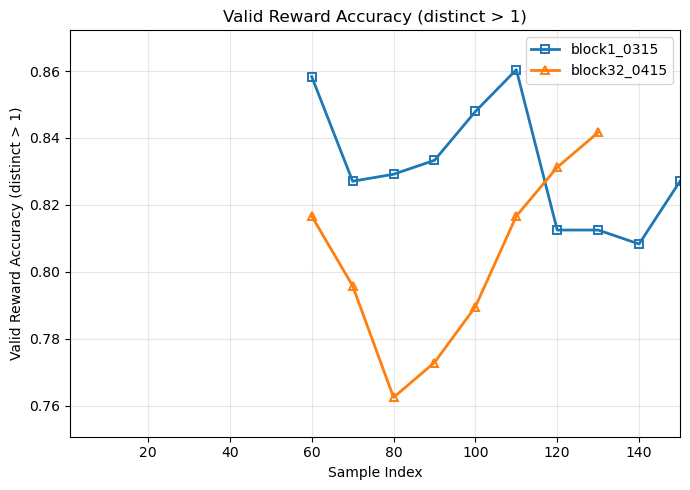

280 points for rollout_diversity in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for rollout_diversity in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/rollout_diversity.png


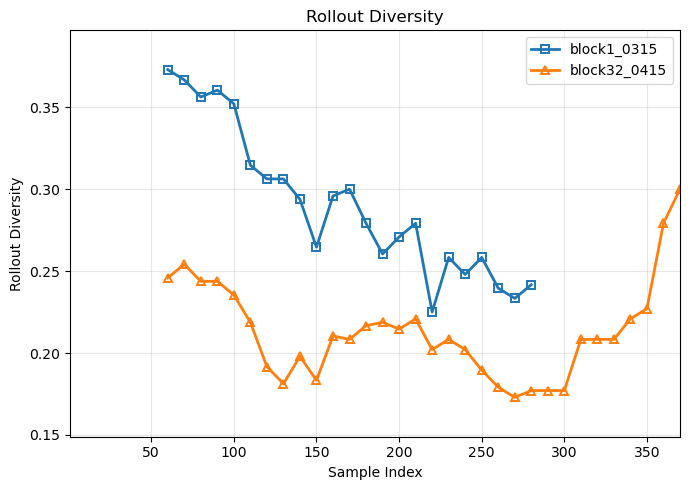

280 points for answer_entropy in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for answer_entropy in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/answer_entropy.png


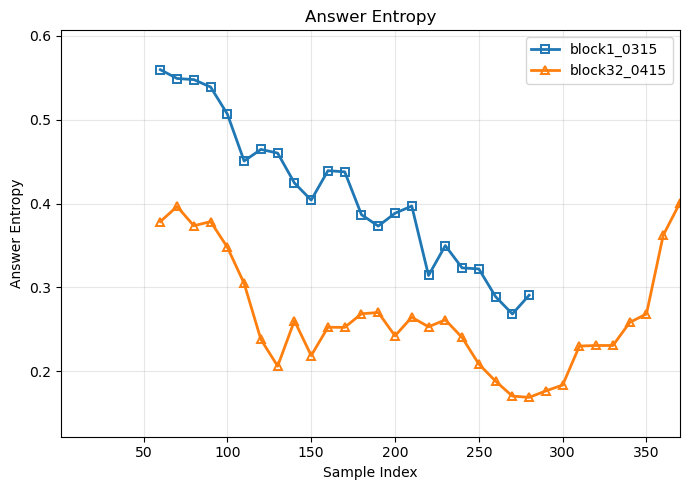

280 points for unique_answer_num in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for unique_answer_num in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/unique_answer_num.png


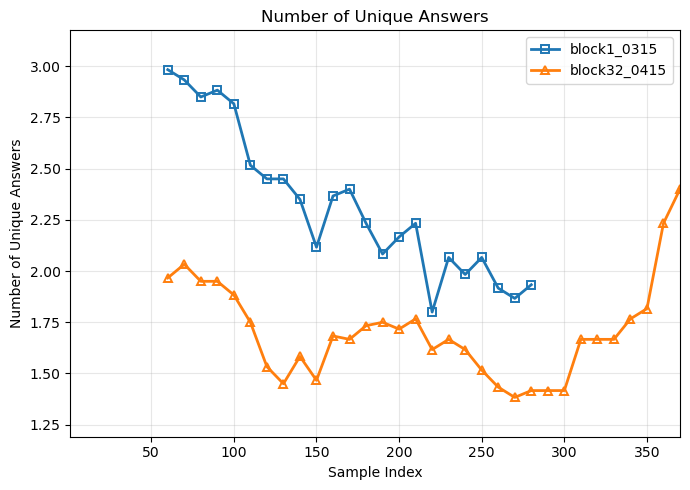

280 points for no_diversity_flag in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for no_diversity_flag in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/no_diversity_flag.png


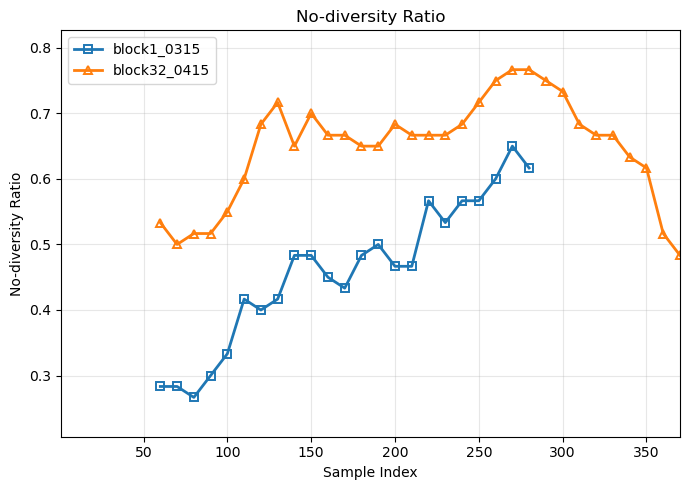

280 points for pass_at_8 in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for pass_at_8 in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/pass_at_8.png


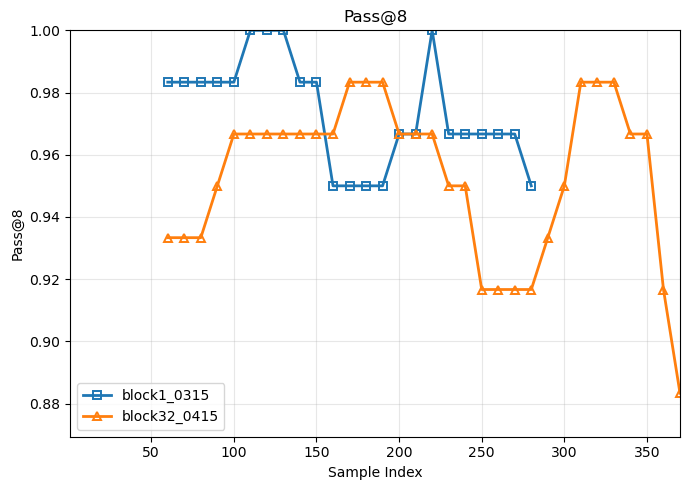

280 points for correct_answer_ratio in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
371 points for correct_answer_ratio in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/correct_answer_ratio.png


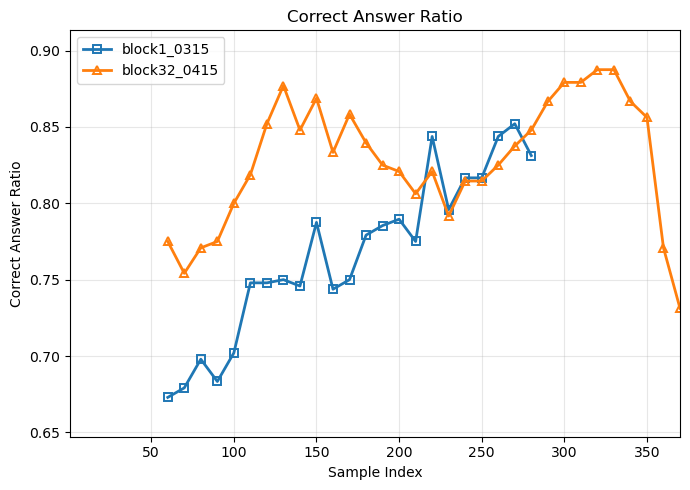

35 points for step_reward in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
41 points for step_reward in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/step_reward.png


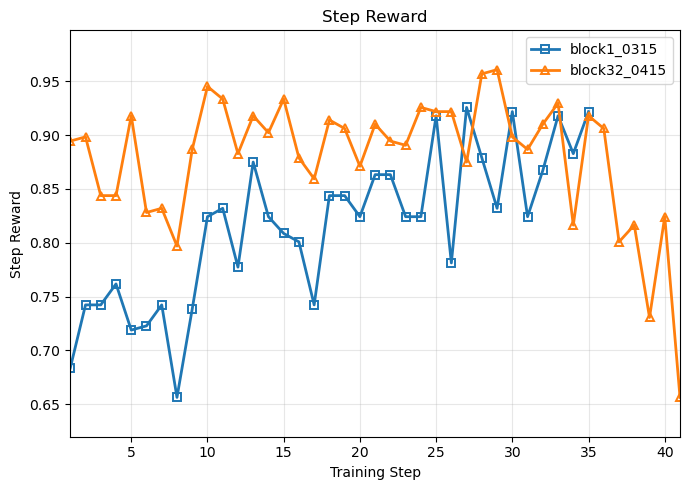

35 points for grad_norm in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
41 points for grad_norm in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/grad_norm.png


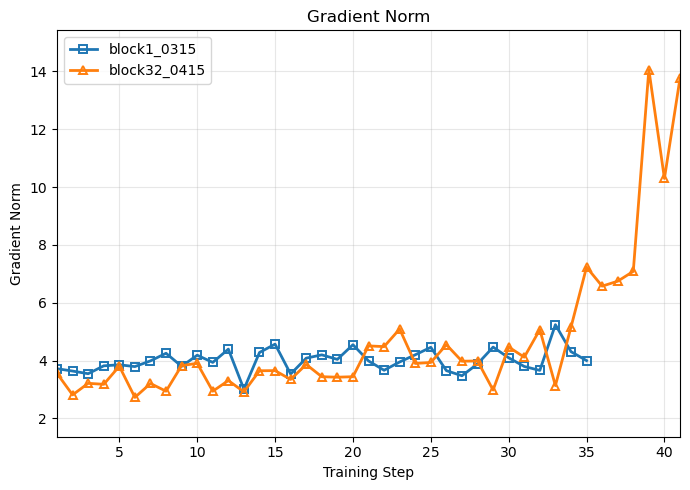

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import ast
import math
from collections import Counter
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
matplotlib.rcParams['axes.unicode_minus'] = False


def moving_average(data, window=10, stride=1):
    """
    Sliding-window moving average.

    window: number of points in each smoothing window
    stride: step size between consecutive windows

    Example:
        window=20, stride=10 means average [0:20], [10:30], [20:40], ...
    """
    data = np.asarray(data, dtype=float)

    if len(data) < window:
        return data, np.arange(1, len(data) + 1)

    y = []
    x = []

    for start in range(0, len(data) - window + 1, stride):
        end = start + window
        y.append(np.nanmean(data[start:end]))
        x.append(end)  # use right endpoint as x-coordinate

    return np.asarray(y), np.asarray(x)


def safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def safe_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default


def parse_list_field(s):
    """
    Parse fields like:
        ['2', '2', '3']
    """
    try:
        value = ast.literal_eval(s)
        if isinstance(value, list):
            return [str(v).strip() for v in value]
        return []
    except Exception:
        return [a.strip().strip("'\"") for a in s.strip('[]').split(',') if a.strip()]


def parse_diversity_line(line):
    try:
        parts = line.strip().split('diversity|', 1)[1].split('|')
        data = {}

        for part in parts:
            part = part.strip()
            if ': ' in part:
                k, v = part.split(': ', 1)
                data[k.strip()] = v.strip()

        extracted_answers = parse_list_field(data.get('extracted_answers', '[]'))

        return {
            'distinct_answer_num': safe_int(data.get('distinct_answer_num', 0)),
            'all_answer_num': safe_int(data.get('all_answer_num', len(extracted_answers))),
            'distinct_answer_ratio': safe_float(data.get('distinct_answer_ratio', 0)),
            'best_answer_ratio': safe_float(data.get('best_answer_ratio', 0)),
            'correct_answer_number': safe_int(data.get('correct_answer_number', 0)),
            'best_is_correct': safe_float(data.get('best_is_correct', 0)),
            'majority_answer': data.get('majority_answer', '').strip(),
            'ground_truth': data.get('ground_truth_answer', '').strip(),
            'extracted_answers': extracted_answers,
        }

    except Exception:
        return None


def parse_step_rewards(log_file):
    rewards = []
    grads = []

    # Example:
    # [Step 1/20] reward=0.7695, grad=4.2632
    pattern = re.compile(
        r'\[Step\s+\d+/\d+\]\s+reward=([-+]?\d*\.?\d+),\s+grad=([-+]?\d*\.?\d+)'
    )

    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards.append(float(m.group(1)))
                grads.append(float(m.group(2)))

    return rewards, grads


def normalized_entropy(answers):
    """
    Normalized answer entropy in [0, 1].
    Higher means the rollout answers are more diverse.
    """
    if not answers:
        return 0.0

    counter = Counter(answers)
    total = sum(counter.values())

    if len(counter) <= 1:
        return 0.0

    probs = [c / total for c in counter.values()]
    entropy = -sum(p * math.log(p + 1e-12) for p in probs)

    return entropy / math.log(len(counter))


def reward_accuracy_from_answers(answers, majority, truth):
    """
    Estimated reward:
        1 if answer == majority_answer else 0

    True reward:
        1 if answer == ground_truth_answer else 0

    Reward accuracy:
        fraction of rollouts where estimated reward agrees with true reward.
    """
    if not answers or majority == '' or truth == '':
        return np.nan

    correct = 0
    total = 0

    for ans in answers:
        est_reward = 1 if ans == majority else 0
        true_reward = 1 if ans == truth else 0
        correct += int(est_reward == true_reward)
        total += 1

    return correct / total if total > 0 else np.nan


def pass_at_k_from_answers(answers, truth, k=8):
    """
    Standard pass@k estimator.

    n: number of generated rollouts
    c: number of correct rollouts

    If k >= n, this becomes pass@n:
        1 if at least one rollout is correct else 0.
    """
    if not answers or truth == '':
        return np.nan

    n = len(answers)
    c = sum(ans == truth for ans in answers)

    if c == 0:
        return 0.0

    if k >= n:
        return 1.0

    if n - c < k:
        return 1.0

    return 1.0 - math.comb(n - c, k) / math.comb(n, k)


def extract_metrics_from_log(log_file):
    metrics = {
        # Diversity-line metrics
        'pseudo_label_acc': [],
        'reward_acc': [],
        'valid_reward_acc': [],
        'rollout_diversity': [],
        'answer_entropy': [],
        'pass_at_8': [],
        'correct_answer_ratio': [],
        'majority_ratio': [],
        'unique_answer_num': [],
        'no_diversity_flag': [],

        # Step-line metrics
        'step_reward': [],
        'grad_norm': [],
    }

    step_rewards, step_grads = parse_step_rewards(log_file)
    metrics['step_reward'] = step_rewards
    metrics['grad_norm'] = step_grads

    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            if 'diversity|' not in line:
                continue

            data = parse_diversity_line(line)
            if data is None:
                continue

            answers = data['extracted_answers']
            majority = data['majority_answer']
            truth = data['ground_truth']
            all_answer_num = data['all_answer_num']
            distinct_answer_num = data['distinct_answer_num']

            if all_answer_num <= 0:
                all_answer_num = len(answers)

            # 1. Pseudo-label accuracy
            if majority != '' and truth != '':
                pseudo_label_acc = 1.0 if majority == truth else 0.0
            else:
                pseudo_label_acc = data['best_is_correct']

            # 2. Reward accuracy, including all samples
            reward_acc = reward_accuracy_from_answers(answers, majority, truth)

            # 3. Valid reward accuracy, filtering no-diversity groups
            if distinct_answer_num > 1:
                valid_reward_acc = reward_acc
            else:
                valid_reward_acc = np.nan

            # 4. Rollout diversity
            if all_answer_num > 0:
                rollout_diversity = distinct_answer_num / all_answer_num
            else:
                rollout_diversity = data['distinct_answer_ratio']

            # 5. Answer entropy
            answer_entropy = normalized_entropy(answers)

            # 6. Pass@8, computed directly from extracted_answers and ground truth
            pass_at_8 = pass_at_k_from_answers(answers, truth, k=8)

            # 7. Correct answer ratio among rollouts
            if truth != '' and answers:
                correct_answer_number = sum(ans == truth for ans in answers)
            else:
                correct_answer_number = data['correct_answer_number']

            correct_answer_ratio = (
                correct_answer_number / all_answer_num
                if all_answer_num > 0 else np.nan
            )

            # 8. Majority ratio
            if answers and majority != '':
                majority_count = sum(ans == majority for ans in answers)
                majority_ratio = majority_count / len(answers)
            else:
                majority_ratio = data['best_answer_ratio']

            # 9. No-diversity flag
            no_diversity_flag = 1.0 if distinct_answer_num <= 1 else 0.0

            metrics['pseudo_label_acc'].append(pseudo_label_acc)
            metrics['reward_acc'].append(reward_acc)
            metrics['valid_reward_acc'].append(valid_reward_acc)
            metrics['rollout_diversity'].append(rollout_diversity)
            metrics['answer_entropy'].append(answer_entropy)
            metrics['pass_at_8'].append(pass_at_8)
            metrics['correct_answer_ratio'].append(correct_answer_ratio)
            metrics['majority_ratio'].append(majority_ratio)
            metrics['unique_answer_num'].append(distinct_answer_num)
            metrics['no_diversity_flag'].append(no_diversity_flag)

    return metrics


def pretty_label(log_file):
    name = Path(log_file).stem
    name = name.replace('checkpoints_', '')
    name = name.replace('_temperature1.0', '')
    name = name.replace('_temperature0.6', '_temp0.6')
    name = name.replace('_lr5e-6', '')
    name = name.replace('gsm8k_num_generation8_test_', '')
    return name


def auto_ylim_from_series(series_list, margin_ratio=0.12, min_span=0.03):
    values = []

    for series in series_list:
        arr = np.asarray(series, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) > 0:
            values.extend(arr.tolist())

    if len(values) == 0:
        return None

    lo, hi = min(values), max(values)
    span = hi - lo

    if span < min_span:
        mid = (lo + hi) / 2
        lo = mid - min_span / 2
        hi = mid + min_span / 2
        span = hi - lo

    lo = lo - span * margin_ratio
    hi = hi + span * margin_ratio

    # For metrics in [0, 1], keep y-axis inside [0, 1]
    if min(values) >= 0 and max(values) <= 1:
        lo = max(0.0, lo)
        hi = min(1.0, hi)

        if hi - lo < min_span:
            if hi >= 0.98:
                lo = max(0.0, hi - min_span)
            elif lo <= 0.02:
                hi = min(1.0, lo + min_span)

    return lo, hi


def plot_metric_across_files(
    log_files,
    metric_name,
    metric_label,
    save_dir=None,
    smooth_window=20,
    smooth_stride=1,
    xlim=None,
    ylim=None,
    min_points=1,
    markevery=1,
):
    plt.figure(figsize=(7, 5))

    plotted = False
    plotted_series = []
    max_x = 0

    markers = ['s', '^', 'o', 'D', 'v', 'P', 'X', '<', '>']

    for file_idx, log_file in enumerate(log_files):
        metrics = extract_metrics_from_log(log_file)
        values = np.asarray(metrics.get(metric_name, []), dtype=float)

        print(len(values), "points for", metric_name, "in", log_file)

        if len(values) == 0:
            print(f"No valid {metric_name} data in {log_file}")
            continue

        # Remove NaN before smoothing
        values_valid = values[~np.isnan(values)]

        if len(values_valid) < min_points:
            print(f"Too few valid {metric_name} points in {log_file}")
            continue

        if len(values_valid) >= smooth_window:
            y_plot, x_plot = moving_average(
                values_valid,
                window=smooth_window,
                stride=smooth_stride,
            )
        else:
            y_plot = values_valid
            x_plot = np.arange(1, len(values_valid) + 1)

        marker = markers[file_idx % len(markers)]

        plt.plot(
            x_plot,
            y_plot,
            linewidth=2,
            label=pretty_label(log_file),
            marker=marker,
            markersize=6,
            markerfacecolor='none',
            markeredgewidth=1.4,
            markevery=markevery,
        )

        plotted_series.append(y_plot)
        max_x = max(max_x, int(x_plot[-1]))
        plotted = True

    if not plotted:
        print(f"No plottable data for {metric_name}")
        plt.close()
        return

    if metric_name in ['step_reward', 'grad_norm']:
        plt.xlabel('Training Step')
    else:
        plt.xlabel('Sample Index')

    plt.ylabel(metric_label)
    plt.title(metric_label)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')

    # X-axis truncation
    if xlim is not None:
        plt.xlim(*xlim)
    else:
        plt.xlim(1, max_x)

    # Y-axis truncation based on smoothed curves
    if ylim is not None:
        plt.ylim(*ylim)
    else:
        auto_ylim = auto_ylim_from_series(plotted_series)
        if auto_ylim is not None:
            plt.ylim(*auto_ylim)

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / f'{metric_name}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')

    plt.show()
    plt.close()


def plot_all_metrics_across_files(
    log_files,
    save_dir=None,
    smooth_window=20,
    smooth_stride=1,
    markevery=1,
):
    metric_specs = [
        # Core URLVR / pseudo-label metrics
        ('pseudo_label_acc', 'Pseudo-label Accuracy'),
        ('reward_acc', 'Reward Accuracy'),
        ('valid_reward_acc', 'Valid Reward Accuracy (distinct > 1)'),

        # Rollout diversity metrics
        # ('rollout_diversity', 'Rollout Diversity'),
        # ('answer_entropy', 'Answer Entropy'),
        # ('unique_answer_num', 'Number of Unique Answers'),
        # ('no_diversity_flag', 'No-diversity Ratio'),

        # Performance proxy metrics
        ('pass_at_8', 'Pass@8'),
        ('correct_answer_ratio', 'Rollout Accuracy'),

        # GRPO training dynamics
        ('step_reward', 'Step Reward'),
        # ('grad_norm', 'Gradient Norm'),
    ]

    for metric_name, metric_label in metric_specs:
        plot_metric_across_files(
            log_files=log_files,
            metric_name=metric_name,
            metric_label=metric_label,
            save_dir=save_dir,
            smooth_window=smooth_window,
            smooth_stride=smooth_stride,
            markevery=markevery,
        )


log_files = [
    'logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log',
    #  'logs/checkpoints_gsm8k_num_generation8_test_block1_temperature0.6_lr5e-6_0424.log',
    'logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log',
   
]

plot_all_metrics_across_files(
    log_files,
    save_dir="plots/",
    smooth_window=60,
    smooth_stride=10,
    markevery=1,
)

Extracted 371 diversity entries from logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Extracted 257 diversity entries from logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log


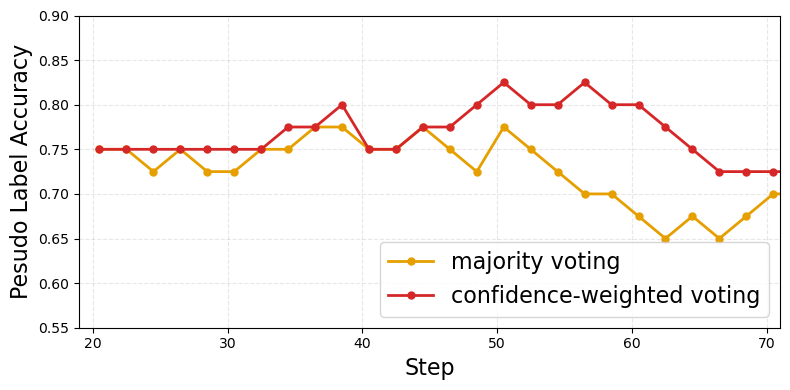

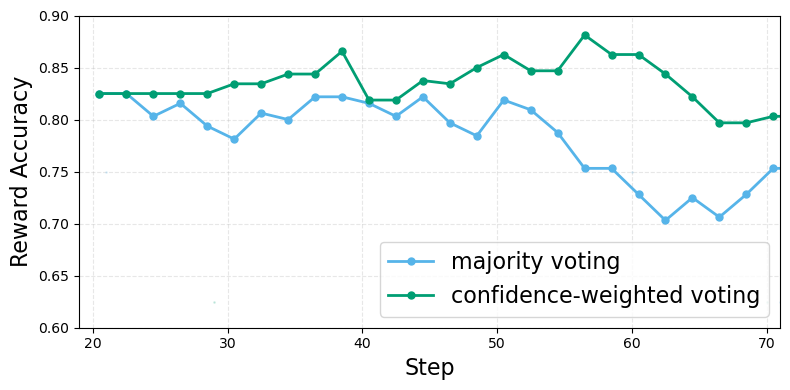


统计信息:
checkpoints_gsm8k_num_generation8_test_block32_0415: Voting=0.7554±0.4299, Reward=0.8273±0.3259
checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank: Voting=0.7600±0.4271, Reward=0.8363±0.3156


In [38]:
def compare_two_logs(log_file1, log_file2, save_dir=None, window_size=40, step_size=3):
    """
    对比两个日志文件的voting accuracy和reward accuracy
    
    Args:
        log_file1: 第一个日志文件路径
        log_file2: 第二个日志文件路径
        save_dir: 保存图片的目录
        window_size: 平滑窗口大小
        step_size: 滑动步长
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
    
    def extract_data(log_file):
        data_list = []
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
        print(f"Extracted {len(data_list)} diversity entries from {log_file}")
        voting_acc_list = []
        reward_acc_list = []
        
        for data in data_list:
            if data['distinct_answer_num'] <= 1:
                continue
            voting_acc_list.append(data['best_is_correct'])
            
            if data['majority_answer'] and data['ground_truth']:
                answers = data['extracted_answers']
                majority = data['majority_answer']
                truth = data['ground_truth']
                tp = fp = tn = fn = 0
                for ans in answers:
                    est_reward = 1 if ans == majority else 0
                    true_reward = 1 if ans == truth else 0
                    if est_reward == 1 and true_reward == 1:
                        tp += 1
                    elif est_reward == 1 and true_reward == 0:
                        fp += 1
                    elif est_reward == 0 and true_reward == 0:
                        tn += 1
                    elif est_reward == 0 and true_reward == 1:
                        fn += 1
                total = tp + fp + tn + fn
                reward_acc_list.append((tp + tn) / total if total > 0 else 0)
            else:
                reward_acc_list.append(0)
        
        return voting_acc_list, reward_acc_list
    
    def sliding_window_avg(data, window, step):
        """滑动窗口平均，步长可调"""
        if len(data) < window:
            return data, np.arange(1, len(data) + 1)
        
        smoothed = []
        x_positions = []
        
        for start in range(0, len(data) - window + 1, step):
            end = start + window
            smoothed.append(np.mean(data[start:end]))
            x_positions.append((start + end) / 2 + 0.5)
        
        return smoothed, x_positions
    
    # 提取数据
    voting1, reward1 = extract_data(log_file1)
    voting2, reward2 = extract_data(log_file2)
    
    if not voting1 and not voting2:
        print("两个文件都没有有效数据")
        return
    
    # 创建两张图
    fig1, ax1 = plt.subplots(figsize=(8, 4))
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    
    name1 = Path(log_file1).stem
    name2 = Path(log_file2).stem
    
    # 四个颜色：橙色、蓝色、绿色、红色
    color_voting1 = '#E69F00'  # 橙色 - majority voting
    color_voting2 = '#d62728'  # 蓝色 - confidence-weighted voting
    color_reward1 = '#56B4E9'  # 绿色 - majority voting reward
    color_reward2 = '#009E73'  # 红色 - confidence-weighted voting reward
    
    # 图1: Voting Accuracy
    if voting1:
        smooth1, x1 = sliding_window_avg(voting1, window_size, step_size)
        ax1.plot(x1, smooth1, 'o-', color=color_voting1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax1.plot(np.arange(1, len(voting1)+1), voting1, '.', color=color_voting1, alpha=0.15, markersize=2)
    
    if voting2:
        smooth2, x2 = sliding_window_avg(voting2, window_size, step_size)
        ax1.plot(x2, smooth2, 'o-', color=color_voting2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax1.plot(np.arange(1, len(voting2)+1), voting2, '.', color=color_voting2, alpha=0.15, markersize=2)
    
    ax1.set_xlabel('Step', fontsize=16)
    ax1.set_ylabel('Pesudo Label Accuracy', fontsize=16)
    ax1.set_xlim(19, 71)
    ax1.set_ylim(0.55, 0.9)
    ax1.legend(loc='lower right', fontsize=16)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 图2: Reward Accuracy
    if reward1:
        smooth1, x1 = sliding_window_avg(reward1, window_size, step_size)
        ax2.plot(x1, smooth1, 'o-', color=color_reward1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax2.plot(np.arange(1, len(reward1)+1), reward1, '.', color=color_reward1, alpha=0.15, markersize=2)
    
    if reward2:
        smooth2, x2 = sliding_window_avg(reward2, window_size, step_size)
        ax2.plot(x2, smooth2, 'o-', color=color_reward2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax2.plot(np.arange(1, len(reward2)+1), reward2, '.', color=color_reward2, alpha=0.15, markersize=2)
    
    ax2.set_xlabel('Step', fontsize=16)
    ax2.set_ylabel('Reward Accuracy', fontsize=16)
    ax2.set_xlim(19, 71)
    ax2.set_ylim(0.6, 0.9)
    ax2.legend(loc='lower right', fontsize=16)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    fig1.tight_layout()
    fig2.tight_layout()
    
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close('all')
    
    # 打印统计
    print("\n" + "="*60)
    print("统计信息:")
    print("="*60)
    if voting1:
        print(f"{name1}: Voting={np.mean(voting1):.4f}±{np.std(voting1):.4f}, Reward={np.mean(reward1):.4f}±{np.std(reward1):.4f}")
    if voting2:
        print(f"{name2}: Voting={np.mean(voting2):.4f}±{np.std(voting2):.4f}, Reward={np.mean(reward2):.4f}±{np.std(reward2):.4f}")


# 使用
log1 = "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log"
log2 = "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log"

compare_two_logs(log1, log2, save_dir="figures", window_size=40, step_size=2)

In [ ]:
colors = {'file1': {'voting': '#1f77b4', 'reward': '#ff7f0e'},
              'file2': {'voting': '#2ca02c', 'reward': '#d62728'}}